# Numpy 과제 #3
### KDT 12기 이재헌
#### 가상의 50명 학생의 키/몸무게 데이터 분석

In [1]:
import numpy as np
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

##### 1) 50명 학생의 키와 몸무게를 아래와 같이 정규 분포로 랜덤하게 생성

In [2]:
population = 50
h_mean = 165
h_std = 8
w_mean = 55
w_std = 10

height = np.random.normal(h_mean, h_std, population)
weight = np.random.normal(w_mean, w_std, population)

print('=== 학생 키/몸무게 데이터 분석 ===')
print(f'데이터 개수: {population}명')
print(f'키 범위: {np.min(height):.1f} ~ {np.max(height):.1f} cm')
print(f'몸무게 범위: {np.min(weight):.1f} ~ {np.max(weight):.1f} kg')

=== 학생 키/몸무게 데이터 분석 ===
데이터 개수: 50명
키 범위: 148.8 ~ 185.4 cm
몸무게 범위: 30.7 ~ 72.2 kg


##### 2) 키와 몸무게의 기술 통계 계산

=== 키 통계 ===
평균: 165.9 cm
중앙값: 166.1 cm
표준편차: 8.6 cm
최소값: 148.8 cm
최대값: 185.4 cm


=== 몸무게 통계 ===
평균: 52.7 kg
중앙값: 53.1 kg
표준편차: 9.3 kg
최소값: 30.7 kg
최대값: 72.2 kg


키 사분위수: [159.6 166.1 172.0]
몸무게 사분위수: [46.5 53.1 59.2]


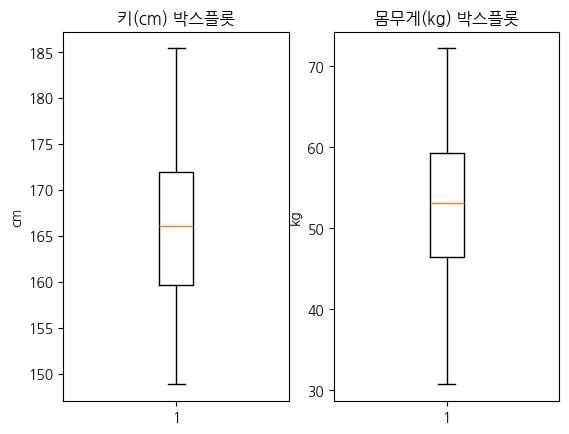

In [3]:
print('=== 키 통계 ===')
print(f'평균: {np.mean(height):.1f} cm')
print(f'중앙값: {np.median(height):.1f} cm')
print(f'표준편차: {np.std(height):.1f} cm')
print(f'최소값: {np.min(height):.1f} cm')
print(f'최대값: {np.max(height):.1f} cm')

print('\n')

print('=== 몸무게 통계 ===')
print(f'평균: {np.mean(weight):.1f} kg')
print(f'중앙값: {np.median(weight):.1f} kg')
print(f'표준편차: {np.std(weight):.1f} kg')
print(f'최소값: {np.min(weight):.1f} kg')
print(f'최대값: {np.max(weight):.1f} kg')

print('\n')

print(f'키 사분위수: [{np.percentile(height, 25):.1f} {np.percentile(height, 50):.1f} {np.percentile(height, 75):.1f}]')
print(f'몸무게 사분위수: [{np.percentile(weight, 25):.1f} {np.percentile(weight, 50):.1f} {np.percentile(weight, 75):.1f}]')

plt.subplot(1,2,1)
plt.boxplot(height)
plt.title('키(cm) 박스플롯')
plt.ylabel('cm')

plt.subplot(1,2,2)
plt.boxplot(weight)
plt.title('몸무게(kg) 박스플롯')
plt.ylabel('kg')

plt.show()

##### 3) 키와 몸무게의 상관 관계 분석 및 산점도(scatter) 그리기

키-몸무게 공분산: -16.51
키-몸무게 상관계수: -0.20


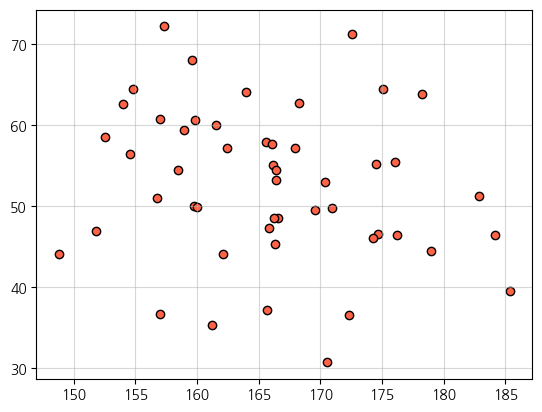

In [4]:
print(f'키-몸무게 공분산: {np.cov(height, weight)[0,1]:.2f}')
print(f'키-몸무게 상관계수: {np.corrcoef(height, weight)[0,1]:.2f}')

plt.scatter(height, weight, color='tomato', edgecolors='k')
plt.grid(alpha=0.5)
plt.show()

##### 4) 키와 몸무게 데이터를 이용한 BMI 계산 (논리 연산)

In [5]:
BMI = weight / ((height/100) ** 2)

print(f'BMI 평균: {np.mean(BMI):.1f}')
print(f'BMI 표준편차: {np.std(BMI):.1f}')

BMI_1 = BMI < 18.5
BMI_2 = np.logical_and(BMI >= 18.5, BMI < 25)
BMI_3 = np.logical_and(BMI >= 25, BMI < 30)
BMI_4 = BMI > 30

print('\n')

print('BMI 분류:')
print(f'저체중(18.5 미만): {np.sum(BMI_1)}명')
print(f'정상(18.5 이상 - 25 미만): {np.sum(BMI_2)}명')
print(f'과체중(25 이상 - 30 미만): {np.sum(BMI_3)}명')
print(f'비만:(30 이상): {np.sum(BMI_4)}명')

BMI 평균: 19.4
BMI 표준편차: 4.3


BMI 분류:
저체중(18.5 미만): 22명
정상(18.5 이상 - 25 미만): 23명
과체중(25 이상 - 30 미만): 5명
비만:(30 이상): 0명
